# Comparison best fit model with human behavior

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from Config.config import PATHS

In [18]:
path_to_data = PATHS['human_data'] / 'multi-player.csv'
data = pd.read_csv(path_to_data)
data['model'] = data.apply(lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1)

path_to_data_sim = PATHS['simulated_data'] / 'FS+Payoff+Attendance.csv'
data_sim = pd.read_csv(path_to_data_sim)
data_sim['treatment'] = 'Best fitting model'
data_sim['model'] = 'FS+Payoff+Attendance'

from Utils.utils import PPT

df = PPT.concat_dfs(data, data_sim)

plot_df = df.copy()
plot_df['source'] = np.where(
    plot_df['model'] == 'FS+Payoff+Attendance',
    'Best fitting model',
    'Humans',
)
plot_df['score_norm'] = plot_df['score'] / plot_df['threshold']
plot_df.tail()

,model,treatment,threshold,num_agents,id_sim,id_player,round,decision,score,source,score_norm
35975,FS+Payoff+Attendance,Best fitting model,0.5,2,56659b56-8864-11f1-a7b7-b48c9db4e1b4,1,17,0.0,0.0,Best fitting model,0.0
35976,FS+Payoff+Attendance,Best fitting model,0.5,2,56659b56-8864-11f1-a7b7-b48c9db4e1b4,0,18,0.0,0.0,Best fitting model,0.0
35977,FS+Payoff+Attendance,Best fitting model,0.5,2,56659b56-8864-11f1-a7b7-b48c9db4e1b4,1,18,1.0,1.0,Best fitting model,2.0
35978,FS+Payoff+Attendance,Best fitting model,0.5,2,56659b56-8864-11f1-a7b7-b48c9db4e1b4,0,19,1.0,1.0,Best fitting model,2.0
35979,FS+Payoff+Attendance,Best fitting model,0.5,2,56659b56-8864-11f1-a7b7-b48c9db4e1b4,1,19,0.0,0.0,Best fitting model,0.0


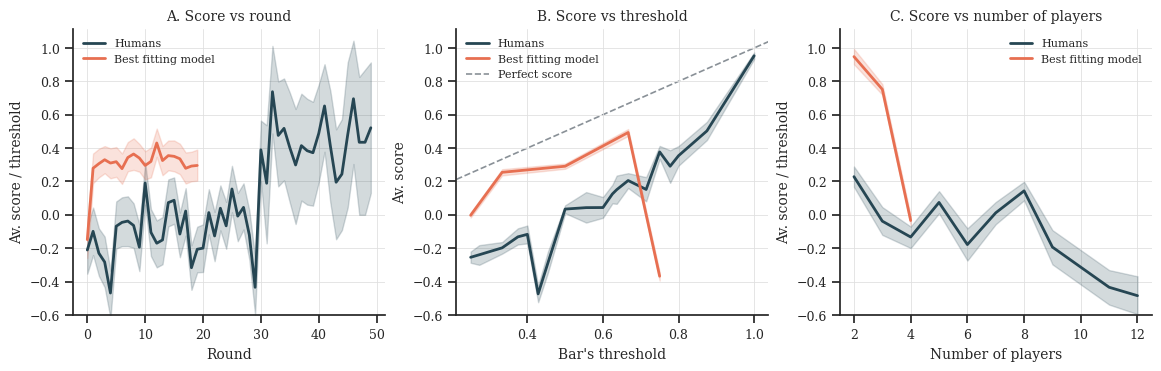

In [19]:
# Publication styling: learning / threshold / players
sns.set_theme(style='ticks', font_scale=1.05)
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

REF_COLOR = '#6C757D'
SOURCE_ORDER = ['Humans', 'Best fitting model']
SOURCE_PALETTE = {
    'Humans': '#264653',
    'Best fitting model': '#E76F51',
}

fig, ax = plt.subplots(
    1, 3,
    figsize=(11.5, 3.6),
    constrained_layout=True,
)

# A. Score vs round (learning within session)
sns.lineplot(
    x='round', y='score_norm', hue='source',
    data=plot_df, ax=ax[0],
    hue_order=SOURCE_ORDER, palette=SOURCE_PALETTE,
    linewidth=2, errorbar=('ci', 95),
)
ax[0].set_xlabel('Round')
ax[0].set_ylabel('Av. score / threshold')
ax[0].set_title('A. Score vs round')
ax[0].grid(True, color='0.88', linewidth=0.6)
ax[0].set_axisbelow(True)
ax[0].legend(frameon=False, fontsize=8, title=None)

# B. Score vs threshold
sns.lineplot(
    x='threshold', y='score', hue='source',
    data=plot_df, ax=ax[1],
    hue_order=SOURCE_ORDER, palette=SOURCE_PALETTE,
    linewidth=2, errorbar=('ci', 95),
)
x_lo, x_hi = ax[1].get_xlim()
ax[1].plot(
    [x_lo, x_hi], [x_lo, x_hi],
    color=REF_COLOR, linestyle='--', linewidth=1.2, alpha=0.8, zorder=0,
    label='Perfect score',
)
ax[1].set_xlim(x_lo, x_hi)
ax[1].set_xlabel("Bar's threshold")
ax[1].set_ylabel('Av. score')
ax[1].set_title('B. Score vs threshold')
ax[1].grid(True, color='0.88', linewidth=0.6)
ax[1].set_axisbelow(True)
ax[1].legend(frameon=False, fontsize=8, title=None)

# C. Score vs number of players
sns.lineplot(
    x='num_agents', y='score_norm', hue='source',
    data=plot_df, ax=ax[2],
    hue_order=SOURCE_ORDER, palette=SOURCE_PALETTE,
    linewidth=2, errorbar=('ci', 95),
)
ax[2].set_xlabel('Number of players')
ax[2].set_ylabel('Av. score / threshold')
ax[2].set_title('C. Score vs number of players')
ax[2].set_ylim(ax[1].get_ylim())
ax[0].set_ylim(ax[1].get_ylim())
ax[2].grid(True, color='0.88', linewidth=0.6)
ax[2].set_axisbelow(True)
ax[2].legend(frameon=False, fontsize=8, title=None)

for a in ax.ravel():
    sns.despine(ax=a)

plt.show()
fig.savefig(PATHS['exploratory_figures'] / 'Fig13.png', dpi=300, bbox_inches='tight')